<a href="https://colab.research.google.com/github/BelkaOukil/test_ml/blob/main/Copy_of_project5_ocean_ssh_superResolution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sorbonnescai/2026_bootcamp_spatial/blob/main/projects/project5_ocean_ssh_superResolution.ipynb)

Initial Presentations can be found [here](https://docs.google.com/presentation/d/1uDtj7WpueLaQCTloqwB_Cyuyc7a6AVn_/edit?usp=drive_link&ouid=114976043584935158832&rtpof=true&sd=true), [here](https://docs.google.com/presentation/d/1Fp-dTRSmgUDCtI46SwgbBa8xmXpl4wfo6KcEMcuV9RQ/edit?usp=sharing) and [here](https://docs.google.com/presentation/d/1tZ2EqIPoI6FXXiWOQwiH8G1Z-HGht2Tz/edit?usp=sharing&ouid=114976043584935158832&rtpof=true&sd=true).






# **Practical on Sea Surface Hight Super-Resolution**

> **This a copy/paste of the original work** **by** <a href="mailto:Carlos.Mejia@locean.ipsl.fr">Carlos Mejia</a> **,** <a href="mailto:theo.archambault@locean.ipsl.fr">Théo Archambault</a> **,** **&** <a href="mailto:anastase.charantonis@ensiie.fr">Anastase Charantonis</a>
>
> With thanks to:
> <style type='text/css'>
.CodeMirror{
font-size: 12px;
</style> &nbsp;&nbsp;&nbsp;&nbsp; Sylvie Thiria, Charles Sorror, Michel Crépon, Paul Nantas & Ayman Ibourg


---



# Loading the files
***
Before anything we will have to acquire the files used in the following ...


**If you are not in colab previously download the data [here](https://drive.google.com/drive/folders/15Jvq7f6_og1v-RK0GdEB8BopKXHstnHP?usp=sharing).**  
**Adapt the code to either your paths if working on your pc, or to your google drive.**

In [ ]:
import sys
IN_COLAB = 'google.colab' in sys.modules
data_dir = './data/'
if IN_COLAB:
  import gdown
  folder_id = "15Jvq7f6_og1v-RK0GdEB8BopKXHstnHP"
  local_folder = "/content/"
  #local_folder = data_dir
  gdown.download_folder(id=folder_id, output=local_folder, resume=True, quiet=True)

# Objectives:

*   *Geophysical:* From a low resolution image of Sea Surface Height (SSH) (and/or other geophysical images of varying resolution) obtain a higher resolution image
*   *Methodological:* Analyse different methods of evaluating your performance, focusing on train/test/validation splits, cross-validation as well as feature engineering and monitoring the learning history
*   *Deep Learning:* Test Convolutional Networks, Residual Networks, or other architectures; test different cost functions & regularization functions
---



# Problem Statement

For several decades, a large variety of satellite sensors has allowed us to dramatically improve the knowledge of the state of planet Earth and its potential evolution thanks to satellite remote sensed imagery. Satellite sensors provide global coverage of the ocean. These sensors are diverse both in terms of remote sensed technology and in geometrical sampling. They observe a multitude of geophysical parameters with various sampling, in space as in time.

They have permitted to better know the ocean state such as **Sea Surface Temperature (SST)** with high resolution radiometers such as the AVHRR sensors launched onboard meteorological satellites, **Sea Surface Height (SSH)** which is a good indicator of ocean circulation with Altimeters (Topex, Poseidon and then Jason altimeters), ocean biological productivity with multispectral ocean color sensors (SeaWIFS, Meris, MODIS, VIIRS) and ocean salinity (SMOS and Aqua).

These satellite sensors have contributed to detect changes in the response of the ocean to global warming. The ocean is a major contributor to the climate state via air sea exchanges (radiative processes, latent and contact heat fluxes), latitudinal heat transport via ocean circulation, climate regulator via the atmospheric CO2 uptake and its enormous heat stockage capacity. These ocean contributions to climate are related to ocean currents through a large variety of scales spanning from basin-scale down to sub-mesoscale (Sasaki et al, 2014, McWilliams, 2016). Moreover, sub-mesoscale ocean currents may play an important role in structuring marine ecosystem (Levy et al, 2018).

In this practical we are going to explore the feasibility of obtaining **higher resolution SSH fields from coarser data.** We will conduct our study in the Gulf stream region (35°N, 55°W) where ocean currents and associated mesoscale dynamics are important, as seen below in the highlighted area:

![gulfStreamRegion_highlight](https://drive.google.com/uc?export=view&id=19Dt_kvvuvlt5GQOUwSh48pSaWWcbXI2v)

In order to facilitate the construction of the different data fields at different resolutions, we use ocean surface simulated data of the Gulf stream region given by the high-resolution ocean model NATL60 whose horizontal resolution is 1/60° in latitude. These simulated observations facilitate the development of algorithms thanks to the possibility to simulate different resolutions and to test the performances of the downscaling algorithms when the SSH images are noisy. This work can further be expanded to either emulate higher resolution fields by running a coarser resolution numerical dynamical model, or to synchronise satelitte data with higher resolution outputs of numerical dynamical models. The full research project focuses also on the U, V fields of oceanic latitudinal and longitudinal circulation.

## The Resolutions

![UVfieldsOfOceanicLatitudinalAndLongitudinalCirculation](https://drive.google.com/uc?export=view&id=1QBClQMax2_aVV3gT5RDPVfPggApocSMo)

The base pixel size of NATL60 is 1/60°th of a degree in latitude, and is refered to as **R01**. For the purposes of this practival, we will work in coarser resolutions, specifically **R09**, **R27** and **R81**, corresponding to a resolution of 9/60°th, 27/60°th and 81/60°th of a degree of latitude, respectivelly. In the practical we will attempt to retreive the SSH at R09, first from SSH at R27, but also try to retreive it from the much coarser R81, or using and combining other variables that can be present at higher resolutions.




### Resolution or pixel coverage

The following table shows pixel size in the study area viewed at different resolutions.

| Data | Number of pixels (Lat $\times$ Lon) | Pixel coverage (${1/100}^{th}$ of degree) | Pixel coverage (km at equator, Lat=$0^o$) |Pixel coverage(km at grid center, Lat=$35.63^o$ N) |
| :----  | :----:          | :----:                  | :----:                       | :----:                         |
| R1     |  1296 x 1377    |        1.3 x 1.7        |        1.5 x 1.9             |           1.5 x 1.5            |
| R3     |   432 x 459     |        4.0 x 5.0        |        4.5 x 5.6             |           4.5 x 4.5            |
| R9     |   144 x 153     |       12.0 x 15.0       |       13.4 x 16.7            |          13.4 x 13.6           |
| R27    |    48 x 51      |       36.1 x 45.1       |       40.1 x 50.1            |          40.1 x 40.7           |
| R81    |    16 x 17      |      108.2 x 135.3      |      120.3 x 150.4           |         120.3 x 122.2          |






### Importing the python libraries:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import random
%matplotlib inline

Some packages to install previously.

In [ ]:
%pip install torchinfo --quiet
%pip install torchsummary --quiet
%pip install torchviz --quiet
%pip install torchvision --quiet

We are going to use pytorch to do some learning. We start by importing some useful modules as well as specific items.

In [ ]:
import torch
from torch.nn import Upsample
from torch import Tensor
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

Most of the learning is gooing to happen on the GPU. Hence pytorch will need to know the device used for learning part.

In [ ]:
if torch.cuda.is_available():
  device = torch.device("cuda")
else:
  device = torch.device("cpu")

# Dataset Presentation

We have 366 daily images of 2 variables (SSH, SST) availiable, spanning from October 1, 2012 up to October 1, 2013. Every image is composed of 1296x1377 pixels by variable, a pixel being a square box of approximately 1.x1. km. This dataset is refered to as R01 but is not present in the drive. In this practical we will only care about R09, R27 and R81, containing  144x153, 48x51  and 16x17 pixels images respectively.

The data cover a geographical area of the North Atlantic Ocean corresponding to the Sargasso Sea.  The northern half is particularly interesting because the Gulf Stream current is strongly visible there through the SSH and SST variables, as you will see in the figures below.

Each variable has three dimensions `[time, lat, lon]` and in the following code, `SSH09[0, :,:]` represents an SSH map for day 0, at resolution R09. Day 0 corresponds to the October 1$^{rst}$, 2012. The SSH is measured in meters (m) and the SST in degrees Celcius (°C). Satellite data is accurate to 0.03m - 0.06m, depending on the sensor.

In [ ]:
SSH09=np.load(data_dir+'NATL60_SSH_R09.npy')
SSH27=np.load(data_dir+'NATL60_SSH_R27.npy')
SSH81=np.load(data_dir+'NATL60_SSH_R81.npy')
SST09=np.load(data_dir+'NATL60_SST_R09.npy')
SST27=np.load(data_dir+'NATL60_SST_R27.npy')
SST81=np.load(data_dir+'NATL60_SST_R81.npy')

### A simple plotting

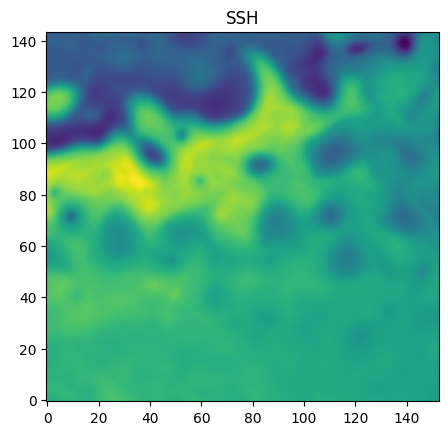

In [ ]:
# a simple exemple of plotting one day SSH chart

# using plt.* commands, adding origin='lower' makes to plot low latitudes at bottom, the real sens of data used
plt.imshow(SSH09[0,:,:],origin='lower')
plt.title('SSH')
plt.show()

### Plotting two variables side by side

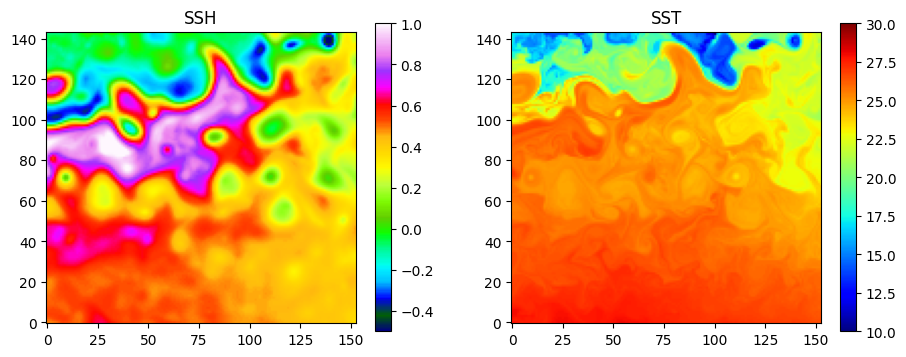

In [ ]:
# ploting two variables in two figures side by side
#  - changing color palette,
#  - setting min and max limits and
#  - adding colorbars.

plt.figure(figsize=(11,4))
# plotting SSH first time step: [0,:,:]
plt.subplot(121)
im = plt.imshow(SSH09[0,:,:],origin='lower',cmap='gist_ncar', vmin=-0.5, vmax=1)
plt.title('SSH')
plt.colorbar(im)
# plotting SST
plt.subplot(122)
im = plt.imshow(SST09[0,:,:],origin='lower',cmap='jet', vmin=10, vmax=30)
plt.title('SST')
plt.colorbar(im)
plt.show()

As you can see, the variables have the greatest variability in the upper half of the figure. This area corresponds to the Gulf Stream area.

### Plotting a variable in three different resolutions

A more sophisticated code using `subplots` in place a `subplot` and using `ax.*` graphic methods in place of `plt.*`; controling also colorbar axe:

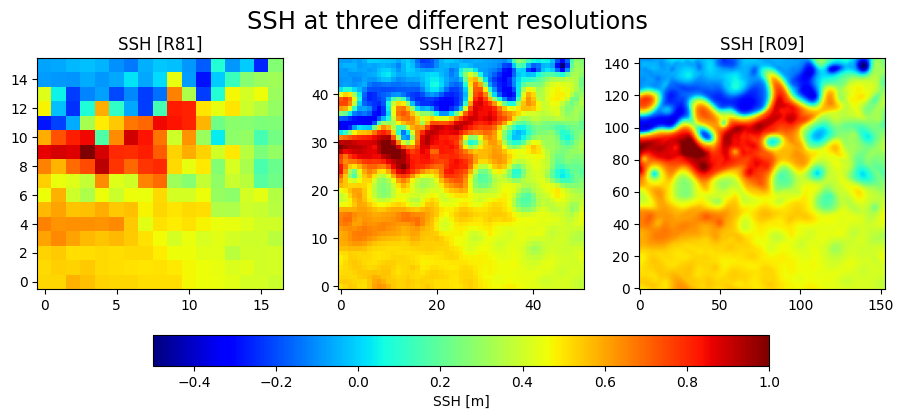

In [ ]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

#  Ploting one variable in three resolutions, side by side
#   colorbar only in last axe

fig,axes = plt.subplots(nrows=1, ncols=3, figsize=(11,4))

iax = 0
# plotting SSH R81, first time step: [0,:,:]
ax = axes[iax]; iax += 1
im = ax.imshow(SSH81[0,:,:],origin='lower',cmap='jet', vmin=-0.5, vmax=1)
ax.set_title('SSH [R81]')

# plotting SSH R27, first time step: [0,:,:]
ax = axes[iax]; iax += 1
im = ax.imshow(SSH27[0,:,:],origin='lower',cmap='jet', vmin=-0.5, vmax=1)
ax.set_title('SSH [R27]')

# plotting SSH R09, first time step: [0,:,:]
ax = axes[iax]; iax += 1
im = ax.imshow(SSH09[0,:,:],origin='lower',cmap='jet', vmin=-0.5, vmax=1)
ax.set_title('SSH [R09]')

# plotting a colorbar common to all axes
cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.1)
cbar.set_label('SSH [m]')

plt.suptitle('SSH at three different resolutions', size='xx-large',y=1.0);

plt.show()

# Splitting it in train / test and validation

Splitting your dataset into train/test and validation is an important part of making sure you are not underfitting or overfitting. There exist multiple different ways to make sure this is the case. In general splitting it into ~60% train, where all our models will be trained, ~20% test with which to compare our models and ~20% validation, to make sure the selected atchitecture does not overfit, is a good rule of thumb. However when faced with a small dataset compared to the number of explicative variables present, it is a good idea to perform *cross-validation*.


![alt text](https://miro.medium.com/max/676/1*RWjVdxk-pcdoGa02t8MLWg.png)

The image above shows the logic of cross validation process with K-folds, where K is 5. In blue is the trainable region, while in red is the test set for each iteration.



In [ ]:
def split_train_test(N,mode="one-fold",K=5,num_test=0,plage=0):
   #returns the indexes of a K-Fold split

   # where N is the total number of samples (images)
   # K stands for the number of folds in K folds
   # num_test is an integer from 0 to K-1 and represents the number of the fold that we use for testing
   # Plage is the number of samples that we live appart in order to decorelate the test ans the train data


        if mode =="one-fold":
            sizetest=N//K

            index=[l for l in range(N)]

            if num_test==0:
                indtest=index[0:sizetest]
                indtrain=index[sizetest+plage:N-plage]

            elif num_test <K-1:
                indtest=index[sizetest*num_test:sizetest*(num_test+1)]
                indtrain=index[0:sizetest*num_test-plage]+index[sizetest*(num_test+1)+plage:N]


            elif num_test ==K-1:
                indtest=index[N-sizetest:N]
                indtrain=index[plage:N-sizetest-plage]

            else:
                print("num_test is over ",K," with value :",num_test)
                return

        if mode =="random":
            index=[l for l in range(N)]
            sizetest=N//K
            random.shuffle(index)
            indtest=sorted(index[0:sizetest])
            indtrain=sorted(index[sizetest:N])
        return indtrain,indtest

def Kfolds_index(N,K=5,plage=15):
  Folds=[]

  for i in range(K):
    Folds.append(split_train_test(N,"one-fold",K,i,plage))
  return Folds

def visualisation_folds(N,K=5,plage=15):
  Folds=Kfolds_index(N,K,15)

  plt.figure(figsize=(20,10))
  k=0
  for index in Folds:
    ind_train,ind_test=index[0],index[1]
    ind_plage=[l for l in range(N) if l not in ind_train and l not in ind_test ]

    train=["train"+str(k)]*len(ind_train)
    test=["test"+str(k)]*len(ind_test)
    plage=["plage"+str(k)]*len(ind_plage)


    plt.subplot(K,1,k+1)
    plt.scatter(ind_train,train,c="blue")
    plt.scatter(ind_plage,plage,c="orange")
    plt.scatter(ind_test,test,c="red")

    k=k+1



For ease of working however, in this practical we would rather split the dataset the following way:

In [ ]:
# une illustration pour voir ...
ind_train,ind_test=split_train_test(366, K=5, num_test=0)
print("*****\nNumber of train samples = ",len(ind_train),"\nNumber of test samples = ",len(ind_test),"\n*****")
del ind_train, ind_test

*****
Number of train samples =  293 
Number of test samples =  73 
*****


# Baseline

It is important, when considering tackling a DL approach to have a baseline approach to compare to, in order to evaluate the utility of incrementing the complexity of your model by comparing the results of the methods and numerical costs of the methods used.



## First idea: bilinear interpolation

Bilinear interpolation is a very simplistic model that might work well. In ML & DL it is always good to start with a simple model to evaluate the need to increse the model's complexity.

In [ ]:
bilin = Upsample(scale_factor=(3,3), mode='bilinear')
# reshaping SSH to have required dimensions. Here: [nb.patterns, nb.channels, nb.lat, nb.lon]; having nb.channels = 1
SSHpattern = np.expand_dims(SSH27, 1)

# applying the UpSampling2D method to the SSH at R27 resolution
SSH09_estimated = bilin(Tensor(SSHpattern))
SSH09_estimated = np.squeeze(SSH09_estimated.detach().numpy()) #removes singleton dimension

# computing the SSH diffenence: real - estimated
#  caution with indices, SSH09 has 3 dimensions but SSH09_estimated has 4,
#  2-nd dimension is the channel, artificially created abobe with reshaping
diff_SSH09 = SSH09 - SSH09_estimated


# bilin = Upsample(scale_factor=(3,3), mode='bilinear')
# SSTpattern = np.expand_dims(SST27, 1)

# SST09_estimated = bilin(Tensor(SSTpattern))
# SST09_estimated = np.squeeze(SST09_estimated.detach().numpy()) #removes singleton dimension


# diff_SST09 = SST09 - SST09_estimated

Some checking to be sure that the dimensions of the data are well understood.

In [ ]:
SSH81.shape,SSH27.shape, SSH09.shape

((366, 16, 17), (366, 48, 51), (366, 144, 153))

In [ ]:
SSHpattern.shape, diff_SSH09.shape

((366, 1, 48, 51), (366, 144, 153))

# Evaluating the results:

### Plotting SSH R09 difference: real - estimated

Plotting the difference between SSH at resolution R09 and the SSH estimated with a `UpSampling2D` layer using a bilinear interpollation method.

We use here a red-blue color chart in order to
assign a meaning to each color: negative values are red, positive values are blue.
This requires that the color bar be centered: `vmin` must be equal to `-vmax`.  Thus the white color falls around zero.  The color map used is `'bwr`.
whose red part normally corresponds to the highest values. We invert it by adding `'_r'` in order to
to attract the red to lower (and negative) values: `'bwr_r'`.

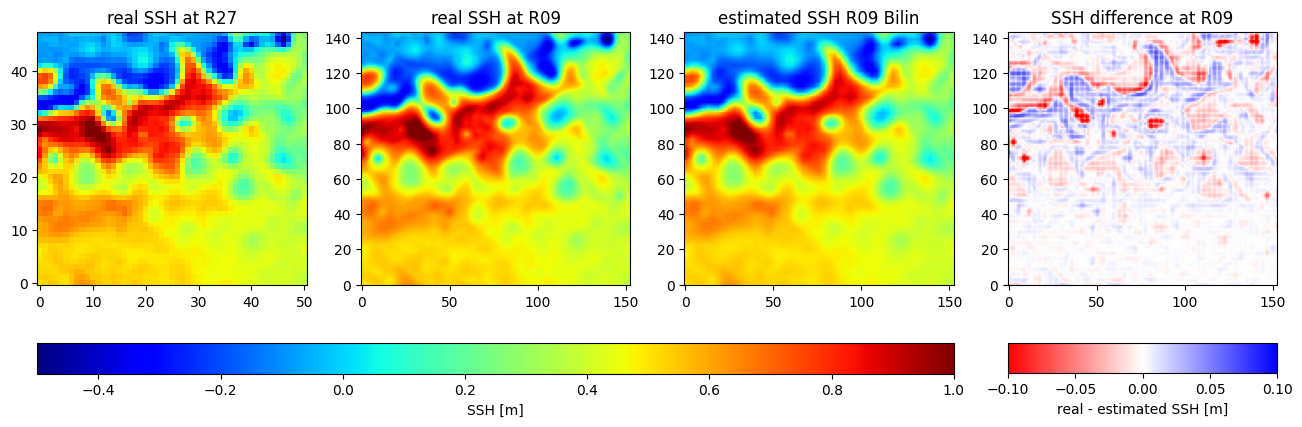

In [ ]:
# plotting the difference between R09 and estimated R09
fig,axes = plt.subplots(nrows=1, ncols=4, figsize=(16,5))

# plotting SSH R27
ax = axes[0]
im = ax.imshow(SSH27[0,:,:],origin='lower',cmap='jet', vmin=-0.5, vmax=1)
ax.set_title('real SSH at R27')

# plotting SSH R09
ax = axes[1]
im = ax.imshow(SSH09[0,:,:],origin='lower',cmap='jet', vmin=-0.5, vmax=1)
ax.set_title('real SSH at R09')

# plotting SSH R09 estimated
ax = axes[2]
im = ax.imshow(SSH09_estimated[0,:,:],origin='lower',cmap='jet', vmin=-0.5, vmax=1)
ax.set_title('estimated SSH R09 Bilin')

# plotting a colorbar common to all SSH axes
cbar = fig.colorbar(im, ax=axes[0:3], orientation='horizontal', aspect=30)
cbar.set_label('SSH [m]')

# plotting SSH R09 difference: real - estimated
ax = axes[3]
im = ax.imshow(diff_SSH09[0,:,:],origin='lower',cmap='bwr_r', vmin=-0.1, vmax=0.1)
ax.set_title('SSH difference at R09')

# making colorbar only for SSH difference ...
cbar = fig.colorbar(im, ax=axes[3], orientation='horizontal', aspect=9)
cbar.set_label('real - estimated SSH [m]') #CARLOS [deg???]



# fig,axes = plt.subplots(nrows=1, ncols=4, figsize=(16,5))

# ax = axes[0]
# im = ax.imshow(SST27[0,:,:],origin='lower',cmap='jet', vmin=-20, vmax=30)
# ax.set_title('real SST at R27')

# ax = axes[1]
# im = ax.imshow(SST09[0,:,:],origin='lower',cmap='jet', vmin=-20, vmax=30)
# ax.set_title('real SST at R09')

# ax = axes[2]
# im = ax.imshow(SST09_estimated[0,:,:],origin='lower',cmap='jet', vmin=-20, vmax=30)
# ax.set_title('estimated SST R09 Bilin')

# cbar = fig.colorbar(im, ax=axes[0:3], orientation='horizontal', aspect=30)
# cbar.set_label('SSH [°C ?]')

# ax = axes[3]
# im = ax.imshow(diff_SST09[0,:,:],origin='lower',cmap='bwr_r', vmin=-0.1, vmax=0.1)
# ax.set_title('SST difference at R09')

# cbar = fig.colorbar(im, ax=axes[3], orientation='horizontal', aspect=9)
# cbar.set_label('real - estimated SST [°C ?]')



### Plotting the difference througth time

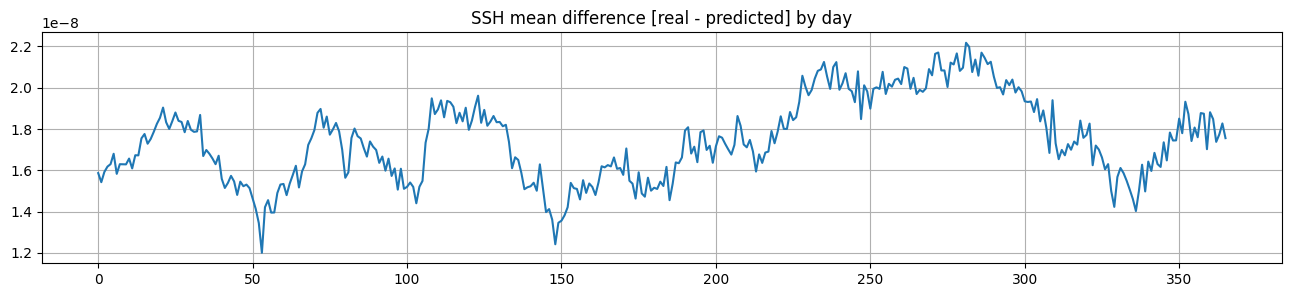

In [ ]:
# mean error of all pixels by day
diff_SSH09_by_day = np.mean(diff_SSH09, axis=(1,2))

# using subplots is interesting even to plot only one axe because they return
plt.figure(figsize=(16,3))
plt.plot(diff_SSH09_by_day)
plt.title('SSH mean difference [real - predicted] by day')
plt.grid(True)



# # mean error of all pixels by day
# diff_SSH09_by_day = np.mean(diff_SST09, axis=(1,2))

# # using subplots is interesting even to plot only one axe because they return
# plt.figure(figsize=(16,3))
# plt.plot(diff_SSH09_by_day)
# plt.title('SST mean difference [real - predicted] by day')
# plt.grid(True)

This error is very small. Is that logical?


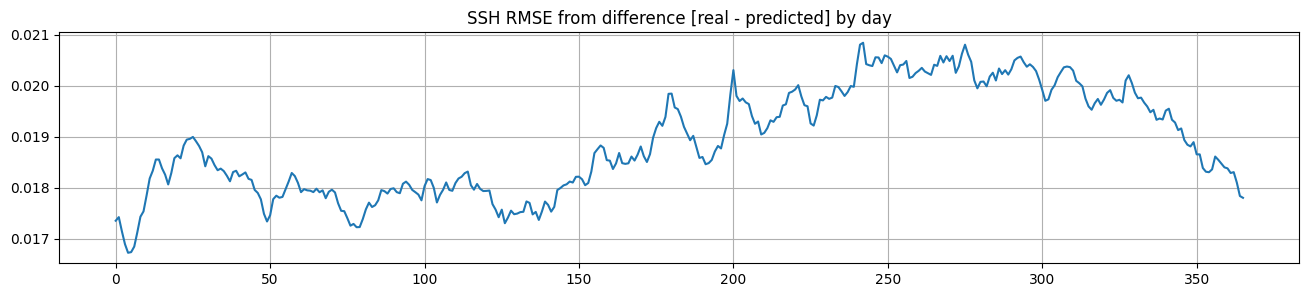

In [ ]:
# root mean square error of all pixels by day
rmse_SSH09_by_day = np.sqrt(np.mean(np.square(diff_SSH09), axis=(1,2)))
#
plt.figure(figsize=(16,3))
plt.plot(rmse_SSH09_by_day)
plt.title('SSH RMSE from difference [real - predicted] by day')
plt.grid(True)


# # root mean square error of all pixels by day
# rmse_SSH09_by_day = np.sqrt(np.mean(np.square(diff_SST09), axis=(1,2)))
# #
# plt.figure(figsize=(16,3))
# plt.plot(rmse_SSH09_by_day)
# plt.title('SST RMSE from difference [real - predicted] by day')
# plt.grid(True)

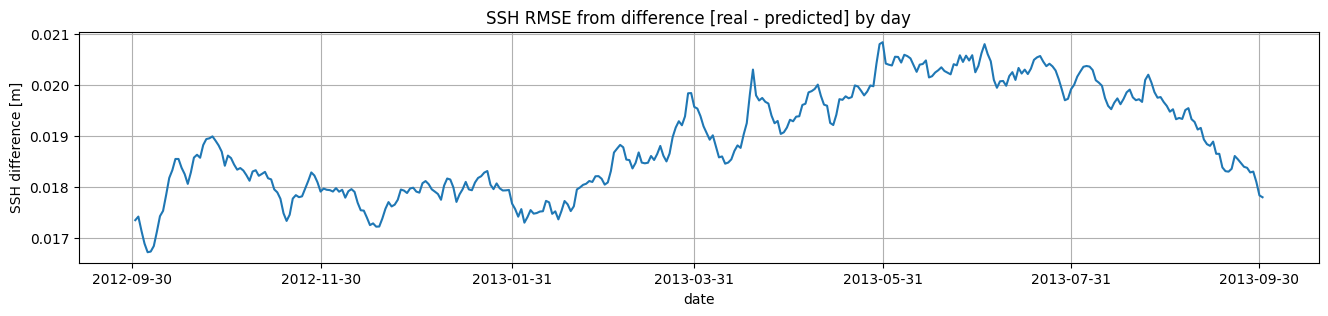

In [ ]:
# addding date using pandas, adding grid
time_vec = pd.date_range("2012-10-01", periods=len(diff_SSH09))
#
plt.figure(figsize=(16,3))
plt.plot(time_vec,rmse_SSH09_by_day)
plt.xlabel('date')
# set xticks each 2 months
plt.xticks(pd.date_range(start="2012-09-01",end="2013-10-01",freq='2ME'))
plt.ylabel('SSH difference [m]')
plt.title('SSH RMSE from difference [real - predicted] by day')
plt.grid(True)

In [ ]:
del SSH09, SSH27, SSH81
del SST09, SST27, SST81

**Shaping data for pytorch**

In [ ]:
import copy
class DatasetR27(Dataset):
  def __init__(self,dirpath=data_dir,input_file="NATL60_SSH_R27.npy",output_file="NATL60_SSH_R09.npy", transform=None):
    self.ind_train, self.ind_test = split_train_test(366, K=5, num_test=0)
    self.input = torch.tensor(np.load(data_dir+input_file), dtype=torch.float32).unsqueeze(1)
    self.target = torch.tensor(np.load(data_dir+output_file), dtype=torch.float32).unsqueeze(1)
    self.index = np.arange(self.input.shape[0])
    self.transform = transform
  def __len__(self):
    return len(self.index)
  def __getitem__(self, index):
    index = self.index[index]
    x, y = self.input[index,:], self.target[index,:]
    if self.transform is not None:
      x, y = self.transform(x), self.transform(y)
    return x, y
  def train(self):
    copied_version = copy.copy(self)
    copied_version.index = self.ind_train
    return copied_version
  def test(self):
    copied_version = copy.copy(self)
    copied_version.index = self.ind_test
    return copied_version


Do we need to transform the data ?

In [ ]:
#transform = transforms.Compose([ ... ])

In [ ]:
dataset = DatasetR27()
batch_size = 16

dataset_learn = dataset.train()
dataset_test = dataset.test()
print(len(dataset), len(dataset_learn), len(dataset_test))

366 293 73


In [ ]:

train_loader = DataLoader(dataset.train(),
                          batch_size=batch_size,
                          shuffle=True,
                          drop_last=False,
                          pin_memory=False)
val_loader   = DataLoader(dataset.test(),
                          batch_size=batch_size,
                          shuffle=True,
                          drop_last=False,
                          pin_memory=False)


# First Neural Netwok: Convolutional Neural Network


## How to build a network with keras
With keras it is very easy to use pre programmed layers in order to build a network. If you want to add a layer at the end of your network you can do :

network  =   mylayer(args) (network)

Like this you specify that you add a layer (mylayer) at the end of the network.

### Exemple in pseudocode:

network=input()

network  =   mylayer1 (args) (network)

network  =   mylayer2 (args) (network)



At the end of this, your network has stacked three layers : input, layers1,layers2.

This formalism is very usefull if you want the models' outputs and inputs to intervene at different parts of your architecture.

Outputs.append(output you want)

In [ ]:
class ConvNet_1(nn.Module):
  def __init__(self, Nfilt=32, upfactor=3):
    super(ConvNet_1, self).__init__()
    # Upsampling (bilinear)
    self.upsample = nn.Upsample(scale_factor=upfactor, mode='bilinear', align_corners=False)
    # The alterning convolution and relu
    self.convEtAl = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=Nfilt, kernel_size=3, padding=1),
                                  nn.ReLU(),
                                  nn.Conv2d(in_channels=Nfilt, out_channels=Nfilt, kernel_size=3, padding=1),
                                  nn.ReLU(),
                                  nn.Conv2d(in_channels=Nfilt, out_channels=8, kernel_size=3, padding=1),
                                  nn.ReLU(),
                                  nn.Conv2d(in_channels=8, out_channels=1, kernel_size=1, padding=0)
                                  )
  def forward(self, x):
      # x shape: (batch_size, 1, NL_, NC_)
      x = self.upsample(x)                  # UpSampling2D
      x = self.convEtAl(x)                  # multiples Conv2D + ReLU
      return x


class test_1(nn.Module):
  def __init__(self, Nfilt=32, upfactor=3):
    super(ConvNet_1, self).__init__()
    # Upsampling (bilinear)
    self.upsample = nn.Upsample(scale_factor=upfactor, mode='bilinear', align_corners=False)
    # The alterning convolution and relu
    self.convEtAl = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=Nfilt, kernel_size=3, padding=1),
                                  nn.ReLU(),
                                  nn.Conv2d(in_channels=Nfilt, out_channels=Nfilt, kernel_size=3, padding=1),
                                  nn.ReLU(),
                                  nn.Conv2d(in_channels=Nfilt, out_channels=8, kernel_size=3, padding=1),
                                  nn.ReLU(),
                                  nn.Conv2d(in_channels=8, out_channels=1, kernel_size=1, padding=0)
                                  )
  def forward(self, x):
      # x shape: (batch_size, 1, NL_, NC_)
      x = self.upsample(x)                  # UpSampling2D
      x = self.convEtAl(x)                  # multiples Conv2D + ReLU
      return x


#nn.Conv2d(in_channels=1, out_channels=Nfilt, kernel_size=3, padding=1)

class ConvNet_2(nn.Module):
    def __init__(self):
        super().__init__()
        self.upsample = nn.Upsample(scale_factor=3, mode='bilinear', align_corners=False)
        self.convEtAl_2 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(16, 1, kernel_size=1, padding=0)
        )

    def forward(self, x):
        # x shape: (batch_size, 1, NL_, NC_)
        x = self.upsample(x)                  # UpSampling2D
        x = self.convEtAl_2(x)                  # multiples Conv2D + ReLU
        return x

class kh_test(nn.Module):
    def __init__(self):
        super().__init__()
        self.upsample = nn.Upsample(scale_factor=3, mode='bilinear', align_corners=False)
        self.convEtAl_3 = nn.Sequential(
            nn.Conv2d(1, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),

            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),

            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),

            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(16),

            nn.Conv2d(16, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(8),

            nn.Conv2d(8, 4, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(4),

            nn.Conv2d(4, 1, kernel_size=1, padding=0)
        )

    def forward(self, x):
        # x shape: (batch_size, 1, NL_, NC_)
        x = self.upsample(x)                  # UpSampling2D
        x = self.convEtAl_3(x)                  # multiples Conv2D + ReLU
        return x


From the class we infer a model. (The model that we are going to use in the following)

In [ ]:
CNN1=ConvNet_1()
# pass it to the device used to learn the parameters
CNN1.to(device)


CNN2=ConvNet_2()
# pass it to the device used to learn the parameters
CNN2.to(device)

CNN3=kh_test()
CNN3.to(device)

kh_test(
  (upsample): Upsample(scale_factor=3.0, mode='bilinear')
  (convEtAl_3): Sequential(
    (0): Conv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


Let us see its structure:

In [ ]:
# a quick display
print(CNN2)

ConvNet_2(
  (net): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)


In [ ]:
# a nicer display
if False:
  from torchsummary import summary
  summary(CNN2, input_size=(1, 48, 51))
from torchinfo import summary
summary(CNN2, input_size=(1, 1, 48, 51))

Layer (type:depth-idx)                   Output Shape              Param #
ConvNet_2                                [1, 1, 144, 153]          --
├─Upsample: 1-1                          [1, 1, 144, 153]          --
├─Sequential: 1-2                        [1, 1, 144, 153]          --
│    └─Conv2d: 2-1                       [1, 16, 144, 153]         160
│    └─ReLU: 2-2                         [1, 16, 144, 153]         --
│    └─Conv2d: 2-3                       [1, 32, 144, 153]         4,640
│    └─ReLU: 2-4                         [1, 32, 144, 153]         --
│    └─Conv2d: 2-5                       [1, 32, 144, 153]         9,248
│    └─ReLU: 2-6                         [1, 32, 144, 153]         --
│    └─Conv2d: 2-7                       [1, 16, 144, 153]         4,624
│    └─ReLU: 2-8                         [1, 16, 144, 153]         --
│    └─Conv2d: 2-9                       [1, 1, 144, 153]          145
Total params: 18,817
Trainable params: 18,817
Non-trainable params: 0
Tota

In [ ]:
# une image pas si claire
from torchviz import make_dot
import torch
x = torch.randn(1, 1, 48, 51).to(device)
y = CNN2(x)
make_dot(y, params=dict(CNN1.named_parameters())).render("CNN1", format="png") ;

In [ ]:
# # TensorBoard n'est pas necessaire ici
# #%reload_ext tensorboard
# %reload_ext tensorboard
# from torch.utils.tensorboard import SummaryWriter
# import torch
# writer = SummaryWriter()
# x = torch.randn(1, 1, 48, 51)
# writer.add_graph(CNN1, x.to(device))
# writer.close()
# %tensorboard --logdir=runs

**We will now have to train and evaluate our model.**  
First of all, a function to learn.

In [ ]:
def train_model(model, dataloaders, optimizer, loss_criterion, num_epochs, loss_history=None):
  if loss_history is None:
    loss_history = {"learn": [], "val": []}
  for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    val_loss = 0.0
    for xb, yb in dataloaders["learn"]:
        # Move tensors to the correct device
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        outputs = model(xb)
        loss = loss_criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(dataloaders["learn"].dataset)
    loss_history["learn"] += [train_loss]
    # Validation
    model.eval()
    with torch.no_grad():
        for xb, yb in dataloaders["val"]:
            # Move tensors to the correct device
            xb = xb.to(device)
            yb = yb.to(device)

            outputs = model(xb)
            loss = loss_criterion(outputs, yb)
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(dataloaders["val"].dataset)
    loss_history["val"] += [val_loss]
    print(f"Epoch {epoch+1:4}/{num_epochs} - loss: {train_loss:.4e} - val_loss: {val_loss:.4e}")
  return loss_history

To learn we need a criterion to optimize.

In [ ]:
criterion_ = nn.MSELoss(reduction='mean')
optimizer_ = optim.Adam(CNN2.parameters())
#criterion_ = nn.MSELoss(reduction='mean')
#optimizer_ = optim.Adam(CNN1.parameters(),
#                        lr=0.001,
#                        betas=(0.9, 0.999),
#                        eps=1e-7   )  # optimizer='adam'

In [ ]:
criterion_og = nn.MSELoss(reduction='mean')
optimizer_og = optim.Adam(CNN1.parameters())

In [ ]:
criterion_kh = nn.MSELoss(reduction='mean')
optimizer_kh = optim.Adam(CNN3.parameters())

We are now able to do a little learning ...

In [ ]:
epochs_ = 10
dataloaders_ = {"learn": train_loader, "val": val_loader}
loss_history = train_model(CNN2, dataloaders_, optimizer_, criterion_, epochs_)

Epoch    1/10 - loss: 7.6431e-02 - val_loss: 7.4802e-03
Epoch    2/10 - loss: 7.0550e-03 - val_loss: 2.9144e-03
Epoch    3/10 - loss: 2.5471e-03 - val_loss: 1.6634e-03
Epoch    4/10 - loss: 1.5379e-03 - val_loss: 1.2336e-03
Epoch    5/10 - loss: 1.1530e-03 - val_loss: 9.3275e-04
Epoch    6/10 - loss: 9.1177e-04 - val_loss: 7.3528e-04
Epoch    7/10 - loss: 7.2053e-04 - val_loss: 5.5067e-04
Epoch    8/10 - loss: 5.5003e-04 - val_loss: 4.2154e-04
Epoch    9/10 - loss: 4.1710e-04 - val_loss: 3.1395e-04
Epoch   10/10 - loss: 3.2599e-04 - val_loss: 2.8839e-04


In [ ]:
# ORIGINAL MODEL
epochs_ = 10
dataloaders_ = {"learn": train_loader, "val": val_loader}
loss_history_og = train_model(CNN1, dataloaders_, optimizer_og, criterion_og, epochs_)

Epoch    1/10 - loss: 7.4792e-02 - val_loss: 2.9863e-03
Epoch    2/10 - loss: 4.9302e-03 - val_loss: 2.2217e-03
Epoch    3/10 - loss: 2.0837e-03 - val_loss: 1.7113e-03
Epoch    4/10 - loss: 1.5354e-03 - val_loss: 1.2947e-03
Epoch    5/10 - loss: 1.1217e-03 - val_loss: 8.7373e-04
Epoch    6/10 - loss: 7.7659e-04 - val_loss: 5.9881e-04
Epoch    7/10 - loss: 5.2473e-04 - val_loss: 3.7589e-04
Epoch    8/10 - loss: 3.3739e-04 - val_loss: 2.5982e-04
Epoch    9/10 - loss: 2.4915e-04 - val_loss: 2.1878e-04
Epoch   10/10 - loss: 2.0754e-04 - val_loss: 1.8014e-04


In [ ]:
epochs_ = 10
dataloaders_ = {"learn": train_loader, "val": val_loader}
loss_history_kh = train_model(CNN3, dataloaders_, optimizer_kh, criterion_kh, epochs_)

Epoch    1/10 - loss: 1.4024e-01 - val_loss: 1.2642e-01
Epoch    2/10 - loss: 9.0223e-02 - val_loss: 1.1329e-01
Epoch    3/10 - loss: 6.9560e-02 - val_loss: 7.1403e-02
Epoch    4/10 - loss: 5.3609e-02 - val_loss: 4.6010e-02
Epoch    5/10 - loss: 3.9976e-02 - val_loss: 3.3202e-02
Epoch    6/10 - loss: 2.8585e-02 - val_loss: 1.9740e-02
Epoch    7/10 - loss: 1.9066e-02 - val_loss: 1.1160e-02
Epoch    8/10 - loss: 1.1932e-02 - val_loss: 7.2058e-03
Epoch    9/10 - loss: 6.9675e-03 - val_loss: 3.4900e-03
Epoch   10/10 - loss: 3.8770e-03 - val_loss: 1.8948e-03


**Did it take forever?**
*If you are in colab, don't forget to go to execution, and modify the type of execution to GPU.*  

Use previous functions to visualise the results! Are they satisfactory?
Have we finished learning ?

In [ ]:
with torch.no_grad():
  predicted_CNN2= CNN2(dataset.input.to(device)).to('cpu').detach().numpy()
diff_SSH09_CNN2 = np.squeeze(dataset.target.numpy() - predicted_CNN2)
rmse_SSH09_by_day_CNN2 = np.sqrt(np.mean(np.square(diff_SSH09_CNN2), axis=(1,2)))

with torch.no_grad():
  predicted_CNN1= CNN1(dataset.input.to(device)).to('cpu').detach().numpy()
diff_SSH09_CNN1 = np.squeeze(dataset.target.numpy() - predicted_CNN1)
rmse_SSH09_by_day_CNN1 = np.sqrt(np.mean(np.square(diff_SSH09_CNN1), axis=(1,2)))


with torch.no_grad():
  predicted_CNN3= CNN3(dataset.input.to(device)).to('cpu').detach().numpy()
diff_SSH09_CNN3 = np.squeeze(dataset.target.numpy() - predicted_CNN3)
rmse_SSH09_by_day_CNN3 = np.sqrt(np.mean(np.square(diff_SSH09_CNN3), axis=(1,2)))



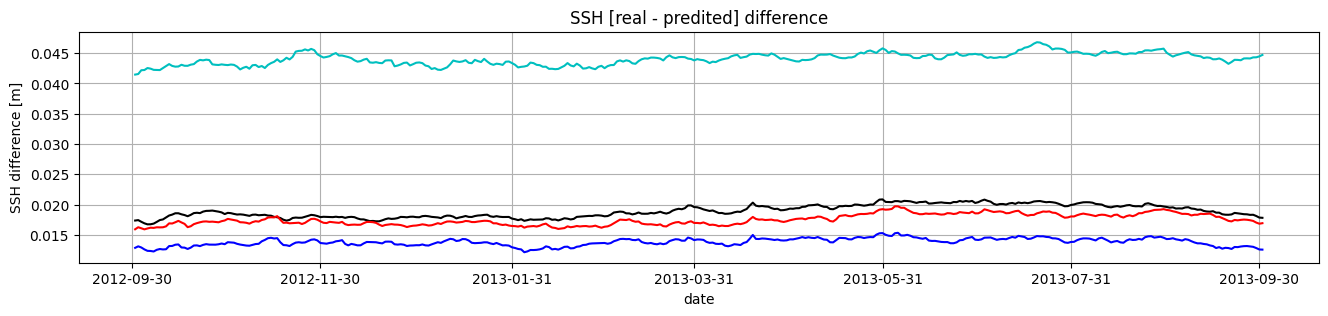

In [ ]:
time_vec = pd.date_range("2012-10-01", periods=len(diff_SSH09))

fig,ax = plt.subplots(nrows=1, ncols=1, figsize=(16,3))

ax.plot(time_vec,rmse_SSH09_by_day,'k')
ax.plot(time_vec,rmse_SSH09_by_day_CNN2,'r')
ax.plot(time_vec,rmse_SSH09_by_day_CNN1, 'b')
ax.plot(time_vec,rmse_SSH09_by_day_CNN3,'c')
ax.grid(True, axis='both')
ax.set_xlabel('date')
# set xticks each 2 months
ax.set_xticks(pd.date_range(start="2012-09-01",end="2013-10-01",freq='2ME'))
ax.set_ylabel('SSH difference [m]')
ax.set_title('SSH [real - predited] difference');

## Further evaluation: Loss curves

In the history object we have many options of what to save about the training process. Here we are showing the metrics that were saved during the initial training of our model.

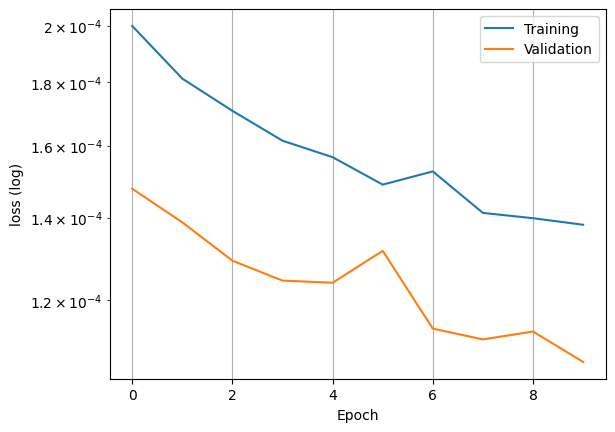

In [ ]:
plt.figure()
plt.semilogy(loss_history_og["learn"], label='Training')
plt.semilogy(loss_history_og["val"], label='Validation')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("loss (log)")
plt.grid(True)
plt.show()

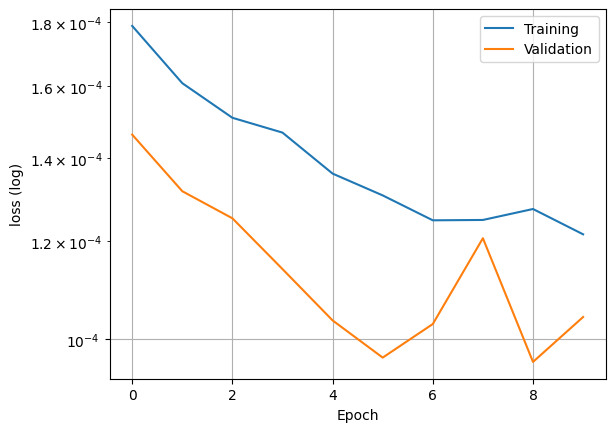

In [ ]:
plt.figure()
plt.semilogy(loss_history["learn"], label='Training')
plt.semilogy(loss_history["val"], label='Validation')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("loss (log)")
plt.grid(True)
plt.show()

What do these curves indicate? Have the curves converged? Are we visibly overfitting? underfitting? should we train more?

In [ ]:
#criterion_ = nn.MSELoss(reduction='mean')                  # loss='mse'
#optimizer_ = optim.Adam(CNN1.parameters(),
#                       lr=0.001,
#                       betas=(0.9, 0.999),
#                       eps=1e-7   )  # optimizer='adam'
#dataloaders_ = {"learn": train_loader, "val": val_loader}
epochs_ = 100
#loss_history = train_model(CNN1, dataloaders_, optimizer_, criterion_, epochs_, loss_history)
# on ne garde pas l'historique
loss_history_og = train_model(CNN1, dataloaders_, optimizer_og, criterion_og, epochs_)

Epoch    1/100 - loss: 3.4085e-03 - val_loss: 9.3113e-04
Epoch    2/100 - loss: 5.3125e-04 - val_loss: 3.1663e-04
Epoch    3/100 - loss: 2.3138e-04 - val_loss: 1.5129e-04
Epoch    4/100 - loss: 1.6608e-04 - val_loss: 1.3046e-04
Epoch    5/100 - loss: 1.4270e-04 - val_loss: 1.0936e-04
Epoch    6/100 - loss: 1.2812e-04 - val_loss: 9.9322e-05
Epoch    7/100 - loss: 1.2110e-04 - val_loss: 9.4993e-05
Epoch    8/100 - loss: 1.1745e-04 - val_loss: 9.2678e-05
Epoch    9/100 - loss: 1.1482e-04 - val_loss: 8.9861e-05
Epoch   10/100 - loss: 1.1213e-04 - val_loss: 8.7515e-05
Epoch   11/100 - loss: 1.1000e-04 - val_loss: 8.5461e-05
Epoch   12/100 - loss: 1.0812e-04 - val_loss: 8.4025e-05
Epoch   13/100 - loss: 1.0699e-04 - val_loss: 8.3285e-05
Epoch   14/100 - loss: 1.0614e-04 - val_loss: 8.2216e-05
Epoch   15/100 - loss: 1.0534e-04 - val_loss: 8.1424e-05
Epoch   16/100 - loss: 1.0463e-04 - val_loss: 8.0800e-05
Epoch   17/100 - loss: 1.0400e-04 - val_loss: 8.0178e-05
Epoch   18/100 - loss: 1.0331e-

In [ ]:
#criterion_ = nn.MSELoss(reduction='mean')                  # loss='mse'
#optimizer_ = optim.Adam(CNN1.parameters(),
#                       lr=0.001,
#                       betas=(0.9, 0.999),
#                       eps=1e-7   )  # optimizer='adam'
#dataloaders_ = {"learn": train_loader, "val": val_loader}
epochs_ = 100
#loss_history = train_model(CNN1, dataloaders_, optimizer_, criterion_, epochs_, loss_history)
# on ne garde pas l'historique
loss_history = train_model(CNN2, dataloaders_, optimizer_, criterion_, epochs_)

Epoch    1/100 - loss: 1.1921e-04 - val_loss: 8.7173e-05
Epoch    2/100 - loss: 1.1310e-04 - val_loss: 8.5583e-05
Epoch    3/100 - loss: 1.1117e-04 - val_loss: 8.0387e-05
Epoch    4/100 - loss: 1.1723e-04 - val_loss: 9.4523e-05
Epoch    5/100 - loss: 1.0849e-04 - val_loss: 7.6772e-05
Epoch    6/100 - loss: 1.0859e-04 - val_loss: 7.9217e-05
Epoch    7/100 - loss: 1.1169e-04 - val_loss: 8.3490e-05
Epoch    8/100 - loss: 1.0437e-04 - val_loss: 8.8965e-05
Epoch    9/100 - loss: 1.0401e-04 - val_loss: 7.7380e-05
Epoch   10/100 - loss: 9.8638e-05 - val_loss: 7.0088e-05
Epoch   11/100 - loss: 1.1948e-04 - val_loss: 8.7872e-05
Epoch   12/100 - loss: 1.0095e-04 - val_loss: 7.0346e-05
Epoch   13/100 - loss: 9.7205e-05 - val_loss: 7.3470e-05
Epoch   14/100 - loss: 9.5028e-05 - val_loss: 6.8300e-05
Epoch   15/100 - loss: 1.0408e-04 - val_loss: 6.9791e-05
Epoch   16/100 - loss: 9.4590e-05 - val_loss: 7.6004e-05
Epoch   17/100 - loss: 9.3048e-05 - val_loss: 6.5843e-05
Epoch   18/100 - loss: 9.9899e-

In [ ]:

epochs_ = 100
# on ne garde pas l'historique
loss_history_kh = train_model(CNN3, dataloaders_, optimizer_kh, criterion_kh, epochs_)

Epoch    1/100 - loss: 2.1715e-03 - val_loss: 1.1851e-03
Epoch    2/100 - loss: 1.2424e-03 - val_loss: 6.0252e-04
Epoch    3/100 - loss: 8.6989e-04 - val_loss: 5.7137e-04
Epoch    4/100 - loss: 7.0421e-04 - val_loss: 4.7723e-04
Epoch    5/100 - loss: 5.5745e-04 - val_loss: 4.8262e-04
Epoch    6/100 - loss: 6.2087e-04 - val_loss: 4.2865e-04
Epoch    7/100 - loss: 5.4533e-04 - val_loss: 3.7026e-04
Epoch    8/100 - loss: 5.1157e-04 - val_loss: 3.5360e-04
Epoch    9/100 - loss: 4.3530e-04 - val_loss: 3.3011e-04
Epoch   10/100 - loss: 4.1892e-04 - val_loss: 3.3666e-04
Epoch   11/100 - loss: 5.7067e-04 - val_loss: 4.5634e-04
Epoch   12/100 - loss: 5.1807e-04 - val_loss: 3.4860e-04
Epoch   13/100 - loss: 3.9428e-04 - val_loss: 2.7855e-04
Epoch   14/100 - loss: 3.7043e-04 - val_loss: 2.7267e-04
Epoch   15/100 - loss: 4.0051e-04 - val_loss: 2.4239e-04
Epoch   16/100 - loss: 4.5587e-04 - val_loss: 3.1272e-04
Epoch   17/100 - loss: 4.2848e-04 - val_loss: 3.6898e-04
Epoch   18/100 - loss: 4.1761e-

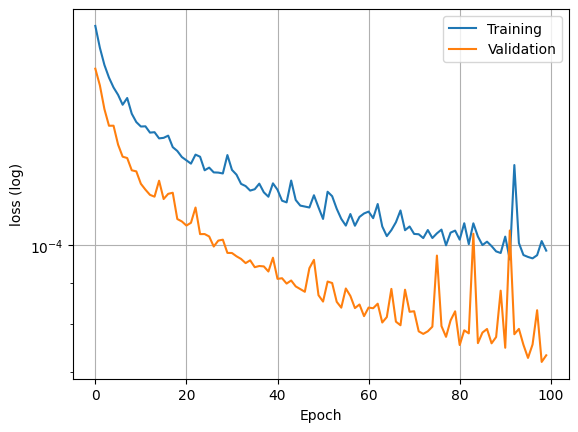

In [ ]:
plt.figure()
plt.semilogy(loss_history_og["learn"], label='Training')
plt.semilogy(loss_history_og["val"], label='Validation')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("loss (log)")
plt.grid(True)
plt.show()

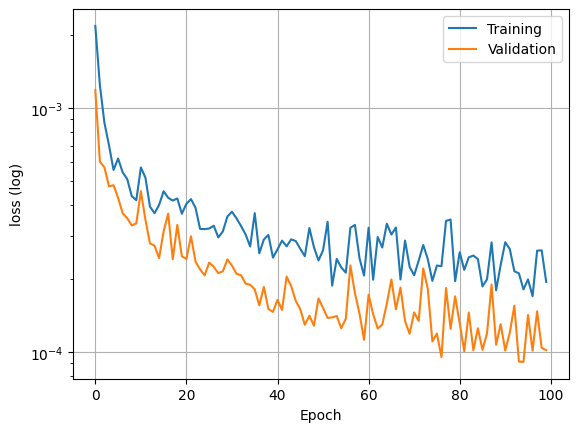

In [ ]:
plt.figure()
plt.semilogy(loss_history["learn"], label='Training')
plt.semilogy(loss_history["val"], label='Validation')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("loss (log)")
plt.grid(True)
plt.show()

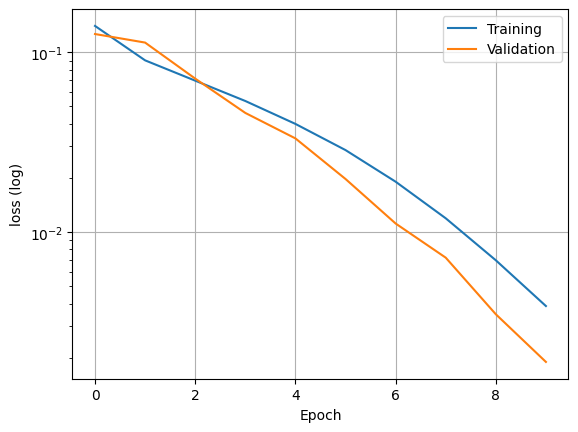

In [ ]:
plt.figure()
plt.semilogy(loss_history_kh["learn"], label='Training')
plt.semilogy(loss_history_kh["val"], label='Validation')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("loss (log)")
plt.grid(True)
plt.show()

*(What do these curves indicate? Is it ok ?  
Have the curves converged? Are we visibly overfitting/underfitting? should we train more?)*

How do the values obtained compare to the ones of the bilin model described before?

/tmp/ipykernel_8393/1722857215.py:15: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'ME' instead.
  ax.set_xticks(pd.date_range(start="2012-09-01",end="2013-10-01",freq='2m'))


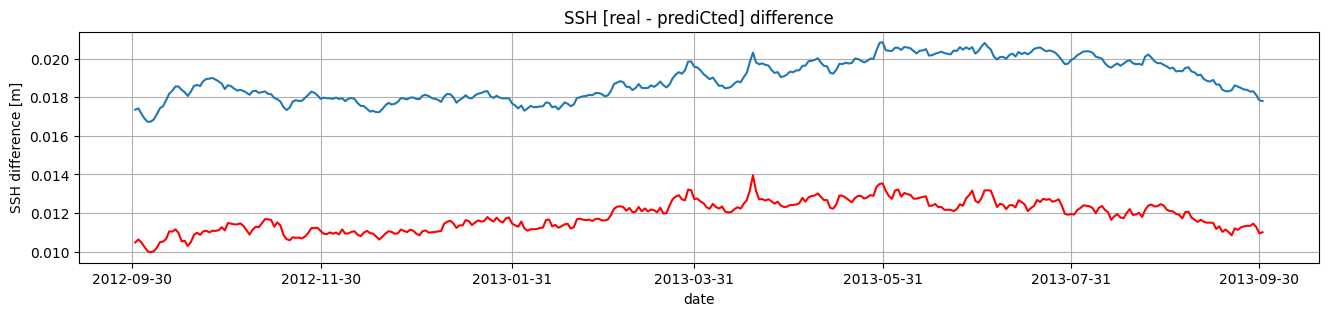

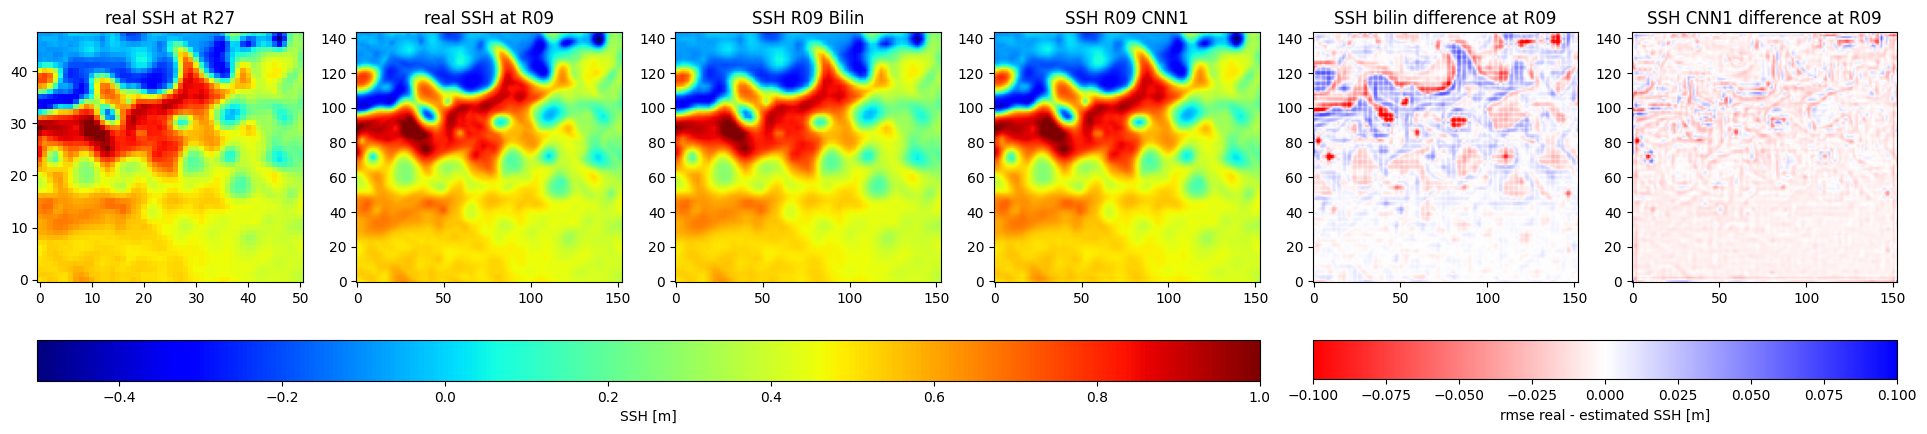

In [ ]:
with torch.no_grad():
  predicted_CNN1= CNN1(dataset.input.to(device)).to('cpu').detach().numpy()
diff_SSH09_CNN1 = np.squeeze(dataset.target.numpy() - predicted_CNN1)
rmse_SSH09_by_day_CNN1 = np.sqrt(np.mean(np.square(diff_SSH09_CNN1), axis=(1,2)))

time_vec = pd.date_range("2012-10-01", periods=len(diff_SSH09_CNN1))

fig,ax = plt.subplots(nrows=1, ncols=1, figsize=(16,3))

ax.plot(time_vec,rmse_SSH09_by_day)
ax.plot(time_vec,rmse_SSH09_by_day_CNN1,'r')
ax.grid(True, axis='both')
ax.set_xlabel('date')
# set xticks each 2 months
ax.set_xticks(pd.date_range(start="2012-09-01",end="2013-10-01",freq='2m'))
ax.set_ylabel('SSH difference [m]')
ax.set_title('SSH [real - prediCted] difference');

# plotting the difference between RO9 and estimated R09
fig,axes = plt.subplots(nrows=1, ncols=6, figsize=(24,5))

# plotting SSH R27
ax = axes[0]
im = ax.imshow(dataset.input[0,:].squeeze().numpy(),origin='lower',cmap='jet', vmin=-0.5, vmax=1)
ax.set_title('real SSH at R27')

# plotting SSH R09
ax = axes[1]
im = ax.imshow(np.squeeze(dataset.target[0,:].numpy()),origin='lower',cmap='jet', vmin=-0.5, vmax=1)
ax.set_title('real SSH at R09')

# plotting SSH R09 estimated by bininear
ax = axes[2]
im = ax.imshow(SSH09_estimated[0,:,:],origin='lower',cmap='jet', vmin=-0.5, vmax=1)
ax.set_title('SSH R09 Bilin')

# plotting SSH R09 estimated by CNN1
ax = axes[3]
im = ax.imshow(np.squeeze(predicted_CNN1[0,:]),origin='lower',cmap='jet', vmin=-0.5, vmax=1)
ax.set_title('SSH R09 CNN1')

# plotting a colorbar common to all SSH axes
cbar = fig.colorbar(im, ax=axes[0:4], orientation='horizontal', aspect=30)
cbar.set_label('SSH [m]')

# plotting SSH R09 difference: real - estimated
ax = axes[4]
im = ax.imshow(diff_SSH09[0,:,:],origin='lower',cmap='bwr_r', vmin=-0.1, vmax=0.1)
ax.set_title('SSH bilin difference at R09')

# plotting SSH R09 difference: real - estimated
ax = axes[5]
im = ax.imshow(diff_SSH09_CNN1[0,:,:],origin='lower',cmap='bwr_r', vmin=-0.1, vmax=0.1)
ax.set_title('SSH CNN1 difference at R09')

# making colorbar only for SSH difference ...
cbar = fig.colorbar(im, ax=axes[4:], orientation='horizontal', aspect=15)
cbar.set_label('rmse real - estimated SSH [m]')



 There should be a visible improvement. Let us focus on the test zone:

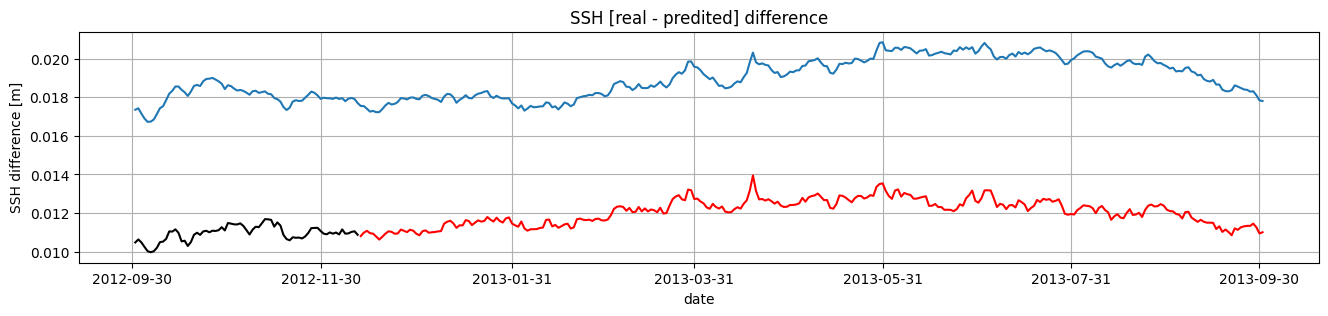

In [ ]:
time_vec = pd.date_range("2012-10-01", periods=len(diff_SSH09))

fig,ax = plt.subplots(nrows=1, ncols=1, figsize=(16,3))

ax.plot(time_vec,rmse_SSH09_by_day)
ax.plot(time_vec[dataset.ind_test],rmse_SSH09_by_day_CNN1[dataset.ind_test],'k')
ax.plot(time_vec[dataset.ind_train],rmse_SSH09_by_day_CNN1[dataset.ind_train],'r')
ax.grid(True, axis='both')
ax.set_xlabel('date')
# set xticks each 2 months
ax.set_xticks(pd.date_range(start="2012-09-01",end="2013-10-01",freq='2ME'))
ax.set_ylabel('SSH difference [m]')
ax.set_title('SSH [real - predited] difference');

The zone for testing was in black. What do we observe?

## Toying around with the model

#### Add some layer / neurons. Modify/add activation functions. Does it improve the model's perfrormance?

Epoch    1/100 - loss: 2.2673e-01 - val_loss: 3.4154e-02
Epoch    2/100 - loss: 1.8381e-02 - val_loss: 1.1731e-02
Epoch    3/100 - loss: 8.6278e-03 - val_loss: 7.9579e-03
Epoch    4/100 - loss: 6.8826e-03 - val_loss: 6.5264e-03
Epoch    5/100 - loss: 5.4576e-03 - val_loss: 5.2378e-03
Epoch    6/100 - loss: 4.0558e-03 - val_loss: 3.6252e-03
Epoch    7/100 - loss: 2.6145e-03 - val_loss: 2.3172e-03
Epoch    8/100 - loss: 1.7551e-03 - val_loss: 1.7442e-03
Epoch    9/100 - loss: 1.3856e-03 - val_loss: 1.4105e-03
Epoch   10/100 - loss: 1.0183e-03 - val_loss: 8.9026e-04
Epoch   11/100 - loss: 6.4815e-04 - val_loss: 6.4232e-04
Epoch   12/100 - loss: 5.0335e-04 - val_loss: 5.2674e-04
Epoch   13/100 - loss: 4.9722e-04 - val_loss: 7.6692e-04
Epoch   14/100 - loss: 4.5420e-04 - val_loss: 4.3819e-04
Epoch   15/100 - loss: 3.6638e-04 - val_loss: 3.9479e-04
Epoch   16/100 - loss: 3.3290e-04 - val_loss: 3.6291e-04
Epoch   17/100 - loss: 3.0447e-04 - val_loss: 3.3039e-04
Epoch   18/100 - loss: 2.7315e-

/tmp/ipykernel_783/2902201173.py:61: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'ME' instead.
  ax.set_xticks(pd.date_range(start="2012-09-01",end="2013-10-01",freq='2m'))


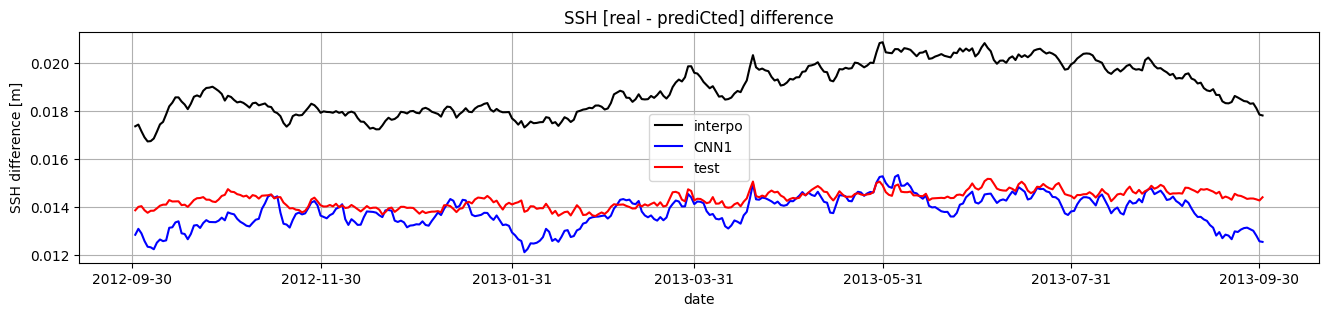

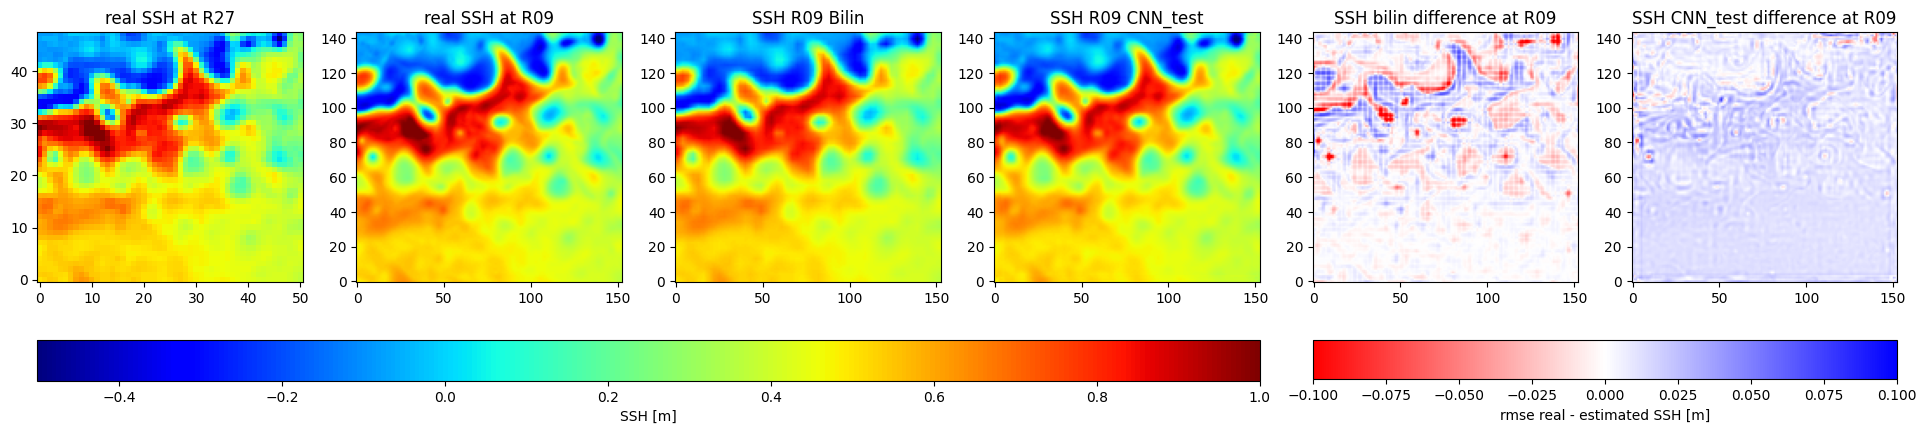

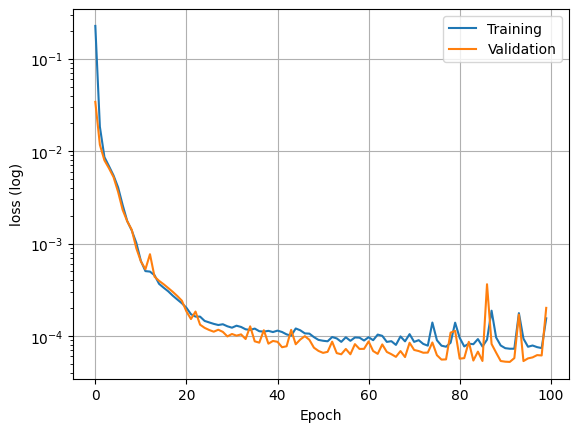

In [ ]:
from matplotlib import legend
class ConvNet_1(nn.Module):
  def __init__(self):
    super(ConvNet_1, self).__init__()
    # Upsampling (bilinear)
    self.upsample = nn.Upsample(scale_factor=3, mode='bilinear', align_corners=False)
    # The alterning convolution and relu
    self.convEtAl_test = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=128, kernel_size=3, padding=1),
                                  nn.ReLU(),
                                  nn.Conv2d(in_channels=128, out_channels=64, kernel_size=3, padding=1),
                                  nn.ReLU(),
                                  nn.Conv2d(in_channels=64, out_channels=32, kernel_size=3, padding=1),
                                  nn.ReLU(),
                                  nn.Conv2d(in_channels=32, out_channels=16, kernel_size=3, padding=1),
                                  nn.ReLU(),
                                  nn.Conv2d(in_channels=16, out_channels=8, kernel_size=3, padding=1),
                                  nn.ReLU(),
                                  nn.Conv2d(in_channels=8, out_channels=4, kernel_size=3, padding=1),
                                  nn.ReLU(),
                                  nn.Conv2d(in_channels=4, out_channels=1, kernel_size=1, padding=0)
                                  )
  def forward(self, x):
      # x shape: (batch_size, 1, NL_, NC_)
      x = self.upsample(x)                  # UpSampling2D
      x = self.convEtAl_test(x)                  # multiples Conv2D + ReLU
      return x


CNN_test=ConvNet_1()
# pass it to the device used to learn the parameters
CNN_test.to(device)


criterion_test = nn.MSELoss(reduction='mean')
optimizer_test = optim.Adam(CNN_test.parameters())


epochs_ = 100
dataloaders_ = {"learn": train_loader, "val": val_loader}
loss_history_test = train_model(CNN_test, dataloaders_, optimizer_test, criterion_test, epochs_)

with torch.no_grad():
  predicted_CNN_test= CNN_test(dataset.input.to(device)).to('cpu').detach().numpy()
diff_SSH09_CNN_test = np.squeeze(dataset.target.numpy() - predicted_CNN_test)
rmse_SSH09_by_day_CNN_test = np.sqrt(np.mean(np.square(diff_SSH09_CNN_test), axis=(1,2)))



#PLOT
time_vec = pd.date_range("2012-10-01", periods=len(diff_SSH09_CNN_test))

fig,ax = plt.subplots(nrows=1, ncols=1, figsize=(16,3))

ax.plot(time_vec,rmse_SSH09_by_day,'k',label='interpo')
ax.plot(time_vec,rmse_SSH09_by_day_CNN1,'b',label='CNN1')
ax.plot(time_vec,rmse_SSH09_by_day_CNN_test,'r',label='test')
ax.legend()
ax.grid(True, axis='both')
ax.set_xlabel('date')
# set xticks each 2 months
ax.set_xticks(pd.date_range(start="2012-09-01",end="2013-10-01",freq='2m'))
ax.set_ylabel('SSH difference [m]')
ax.set_title('SSH [real - prediCted] difference');

# plotting the difference between RO9 and estimated R09
fig,axes = plt.subplots(nrows=1, ncols=6, figsize=(24,5))

# plotting SSH R27
ax = axes[0]
im = ax.imshow(dataset.input[0,:].squeeze().numpy(),origin='lower',cmap='jet', vmin=-0.5, vmax=1)
ax.set_title('real SSH at R27')

# plotting SSH R09
ax = axes[1]
im = ax.imshow(np.squeeze(dataset.target[0,:].numpy()),origin='lower',cmap='jet', vmin=-0.5, vmax=1)
ax.set_title('real SSH at R09')

# plotting SSH R09 estimated by bininear
ax = axes[2]
im = ax.imshow(SSH09_estimated[0,:,:],origin='lower',cmap='jet', vmin=-0.5, vmax=1)
ax.set_title('SSH R09 Bilin')

# plotting SSH R09 estimated by CNN1
ax = axes[3]
im = ax.imshow(np.squeeze(predicted_CNN_test[0,:]),origin='lower',cmap='jet', vmin=-0.5, vmax=1)
ax.set_title('SSH R09 CNN_test')

# plotting a colorbar common to all SSH axes
cbar = fig.colorbar(im, ax=axes[0:4], orientation='horizontal', aspect=30)
cbar.set_label('SSH [m]')

# plotting SSH R09 difference: real - estimated
ax = axes[4]
im = ax.imshow(diff_SSH09[0,:,:],origin='lower',cmap='bwr_r', vmin=-0.1, vmax=0.1)
ax.set_title('SSH bilin difference at R09')

# plotting SSH R09 difference: real - estimated
ax = axes[5]
im = ax.imshow(diff_SSH09_CNN_test[0,:,:],origin='lower',cmap='bwr_r', vmin=-0.1, vmax=0.1)
ax.set_title('SSH CNN_test difference at R09')

# making colorbar only for SSH difference ...
cbar = fig.colorbar(im, ax=axes[4:], orientation='horizontal', aspect=15)
cbar.set_label('rmse real - estimated SSH [m]')



plt.figure()
plt.semilogy(loss_history_test["learn"], label='Training')
plt.semilogy(loss_history_test["val"], label='Validation')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("loss (log)")
plt.grid(True)
plt.show()

#### Is normalization useful with only one variable? (*How to normalize properly?*)

#### Schedulers, what are they good for? (*Is it a priority here?*)
There are some parameters of neural networks that greatly benefit from being changed over the training epochs.

# Going Deeper (actually wider)

R27 to R09 is relativelly simple. In this part we will try to go from R81 to R09.  
*(Like previously try a bilinear approach first.)*  
Here, we will have to compare the results relatively to the simpler task.


/tmp/ipykernel_783/2849856112.py:13: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'ME' instead.
  ax.set_xticks(pd.date_range(start="2012-09-01",end="2013-10-01",freq='2m'))


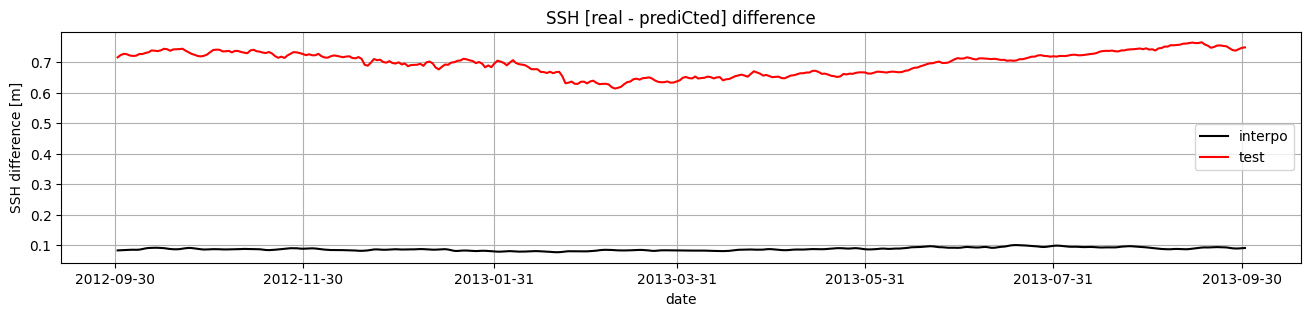

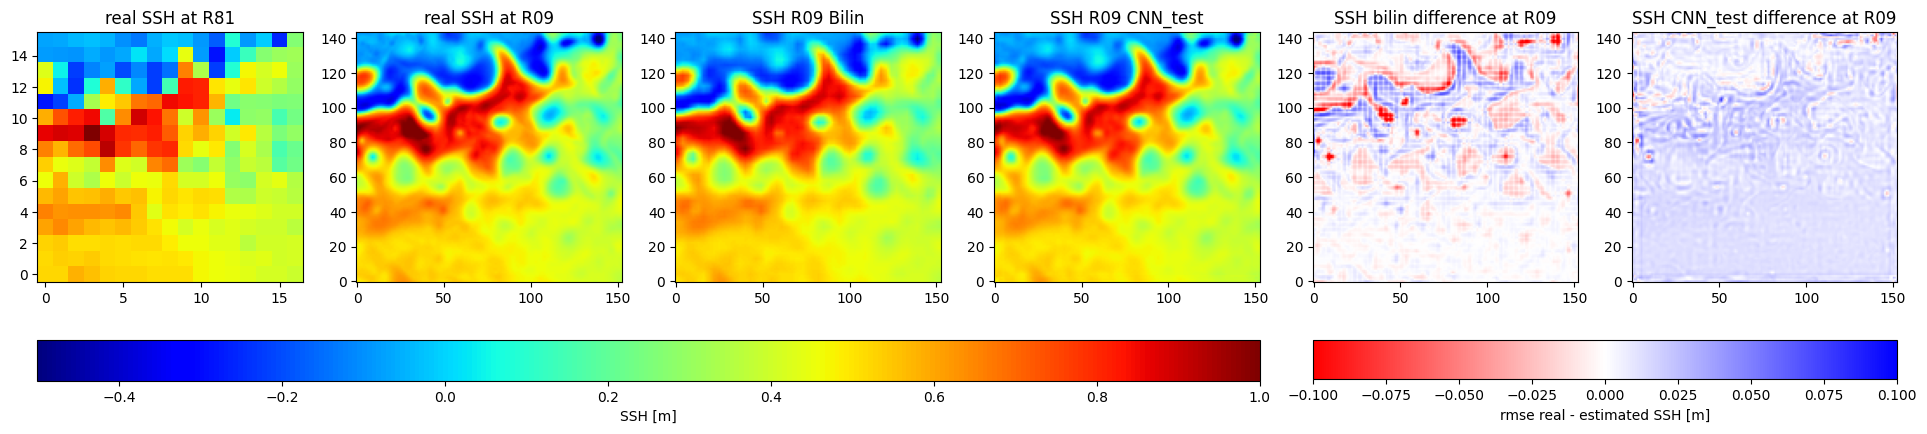

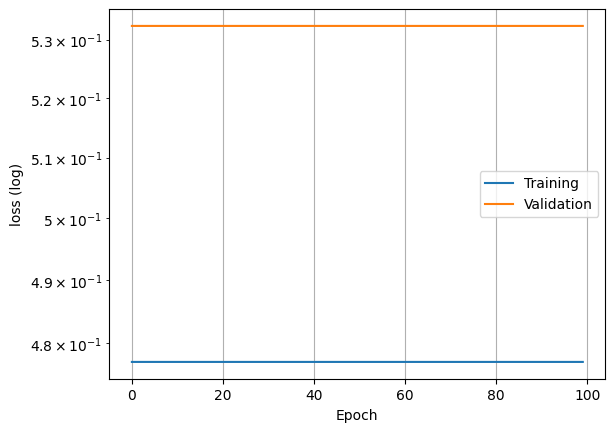

In [ ]:
from matplotlib import legend

bilin_81 = Upsample(scale_factor=(9,9), mode='bilinear')
# reshaping SSH to have required dimensions. Here: [nb.patterns, nb.channels, nb.lat, nb.lon]; having nb.channels = 1
SSHpattern = np.expand_dims(SSH81, 1)

# applying the UpSampling2D method to the SSH at R81 resolution
SSH09_test_estimated = bilin_81(Tensor(SSHpattern))
SSH09_test_estimated = np.squeeze(SSH09_test_estimated.detach().numpy()) #removes singleton dimension

diff_SSH09_test = SSH09 - SSH09_test_estimated


rmse_SSH27_by_day_81 = np.sqrt(np.mean(np.square(diff_SSH09_test), axis=(1,2)))



# PLOT

# plotting the difference between R09 and estimated R09
fig,axes = plt.subplots(nrows=1, ncols=4, figsize=(16,5))

# plotting SSH R81
ax = axes[0]
im = ax.imshow(SSH81[0,:,:],origin='lower',cmap='jet', vmin=-0.5, vmax=1)
ax.set_title('real SSH at R81')

# plotting SSH R27
ax = axes[1]
im = ax.imshow(SSH09[0,:,:],origin='lower',cmap='jet', vmin=-0.5, vmax=1)
ax.set_title('real SSH at R27')

# plotting SSH R27 estimated
ax = axes[2]
im = ax.imshow(SSH09_test_estimated[0,:,:],origin='lower',cmap='jet', vmin=-0.5, vmax=1)
ax.set_title('estimated SSH R27 Bilin')

# plotting a colorbar common to all SSH axes
cbar = fig.colorbar(im, ax=axes[0:3], orientation='horizontal', aspect=30)
cbar.set_label('SSH [m]')

# plotting SSH R09 difference: real - estimated
ax = axes[3]
im = ax.imshow(diff_SSH09_test[0,:,:],origin='lower',cmap='bwr_r', vmin=-0.1, vmax=0.1)
ax.set_title('SSH difference at R27')

# making colorbar only for SSH difference ...
cbar = fig.colorbar(im, ax=axes[3], orientation='horizontal', aspect=9)
cbar.set_label('real - estimated SSH [m]') #CARLOS [deg???]












dataset = DatasetR27(input_file="NATL60_SSH_R81.npy")
batch_size = 16

dataset_learn = dataset.train()
dataset_test = dataset.test()
print(len(dataset), len(dataset_learn), len(dataset_test))

train_loader = DataLoader(dataset.train(),
                          batch_size=batch_size,
                          shuffle=True,
                          drop_last=False,
                          pin_memory=False)
val_loader   = DataLoader(dataset.test(),
                          batch_size=batch_size,
                          shuffle=True,
                          drop_last=False,
                          pin_memory=False)





###############
# RUN MODEL on 81 to 27 then use previous MODEL 27 to 09
###############





class ConvNet_81(nn.Module):
  def __init__(self):
    super(ConvNet_81, self).__init__()
    # Upsampling (bilinear)
    self.upsample = nn.Upsample(scale_factor=9, mode='bilinear', align_corners=False)
    # The alterning convolution and relu
    self.convEtAl_81_test = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=128, kernel_size=3, padding=1),
                                  nn.ReLU(),
                                  nn.Conv2d(in_channels=128, out_channels=64, kernel_size=3, padding=1),
                                  nn.ReLU(),
                                  nn.Conv2d(in_channels=64, out_channels=32, kernel_size=3, padding=1),
                                  nn.ReLU(),
                                  nn.Conv2d(in_channels=32, out_channels=16, kernel_size=3, padding=1),
                                  nn.ReLU(),
                                  nn.Conv2d(in_channels=16, out_channels=8, kernel_size=3, padding=1),
                                  nn.ReLU(),
                                  nn.Conv2d(in_channels=8, out_channels=4, kernel_size=3, padding=1),
                                  nn.ReLU(),
                                  nn.Conv2d(in_channels=4, out_channels=1, kernel_size=1, padding=0)
                                  )
  def forward(self, x):
      # x shape: (batch_size, 1, NL_, NC_)
      x = self.upsample(x)                  # UpSampling2D
      x = self.convEtAl_81_test(x)          # multiples Conv2D + ReLU
      return x


CNN_81_test=ConvNet_81()
# pass it to the device used to learn the parameters
CNN_81_test.to(device)


criterion_81_test = nn.MSELoss(reduction='mean')
optimizer_81_test = optim.Adam(CNN_test.parameters())


epochs_ = 100
dataloaders_ = {"learn": train_loader, "val": val_loader}
loss_history_test = train_model(CNN_81_test, dataloaders_, optimizer_81_test, criterion_81_test, epochs_)

with torch.no_grad():
  predicted_CNN_81_test= CNN_81_test(dataset.input.to(device)).to('cpu').detach().numpy()
diff_SSH09_CNN_81_test = np.squeeze(dataset.target.numpy() - predicted_CNN_81_test)
rmse_SSH09_by_day_CNN_81_test = np.sqrt(np.mean(np.square(diff_SSH09_CNN_81_test), axis=(1,2)))



#PLOT
time_vec = pd.date_range("2012-10-01", periods=len(diff_SSH09_CNN_81_test))

fig,ax = plt.subplots(nrows=1, ncols=1, figsize=(16,3))

ax.plot(time_vec,rmse_SSH27_by_day_81,'k',label='interpo')
# ax.plot(time_vec,rmse_SSH09_by_day_CNN1,'b',label='CNN1')
ax.plot(time_vec,rmse_SSH09_by_day_CNN_81_test,'r',label='test')
ax.legend()
ax.grid(True, axis='both')
ax.set_xlabel('date')
# set xticks each 2 months
ax.set_xticks(pd.date_range(start="2012-09-01",end="2013-10-01",freq='2m'))
ax.set_ylabel('SSH difference [m]')
ax.set_title('SSH [real - prediCted] difference');

# plotting the difference between RO9 and estimated R09
fig,axes = plt.subplots(nrows=1, ncols=6, figsize=(24,5))

# plotting SSH R81
ax = axes[0]
im = ax.imshow(dataset.input[0,:].squeeze().numpy(),origin='lower',cmap='jet', vmin=-0.5, vmax=1)
ax.set_title('real SSH at R81')

# plotting SSH R09
ax = axes[1]
im = ax.imshow(np.squeeze(dataset.target[0,:].numpy()),origin='lower',cmap='jet', vmin=-0.5, vmax=1)
ax.set_title('real SSH at R09')

# plotting SSH R09 estimated by bininear
ax = axes[2]
im = ax.imshow(SSH09_estimated[0,:,:],origin='lower',cmap='jet', vmin=-0.5, vmax=1)
ax.set_title('SSH R09 Bilin')

# plotting SSH R09 estimated by CNN
ax = axes[3]
im = ax.imshow(np.squeeze(predicted_CNN_test[0,:]),origin='lower',cmap='jet', vmin=-0.5, vmax=1)
ax.set_title('SSH R09 CNN_test')

# plotting a colorbar common to all SSH axes
cbar = fig.colorbar(im, ax=axes[0:4], orientation='horizontal', aspect=30)
cbar.set_label('SSH [m]')

# plotting SSH R09 difference: real - estimated
ax = axes[4]
im = ax.imshow(diff_SSH09[0,:,:],origin='lower',cmap='bwr_r', vmin=-0.1, vmax=0.1)
ax.set_title('SSH bilin difference at R09')

# plotting SSH R09 difference: real - estimated
ax = axes[5]
im = ax.imshow(diff_SSH09_CNN_test[0,:,:],origin='lower',cmap='bwr_r', vmin=-0.1, vmax=0.1)
ax.set_title('SSH CNN_test difference at R09')

# making colorbar only for SSH difference ...
cbar = fig.colorbar(im, ax=axes[4:], orientation='horizontal', aspect=15)
cbar.set_label('rmse real - estimated SSH [m]')



plt.figure()
plt.semilogy(loss_history_test["learn"], label='Training')
plt.semilogy(loss_history_test["val"], label='Validation')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("loss (log)")
plt.grid(True)
plt.show()

## Adding information to the network

Let us see if the same architecture works better when adding SST at the higher resolution:

Adding it at both resolutions:

Did you normalize the SST and SSH data?

## A cost function at both resolutions
We can output results at different resolutions and our cost function can then try to optimize reconstructing all resolutions.

## A cost function for Geoscientists

When we are using the MSE error, we tend to assume that all errors will have the same standard deviation. There is a quiet assumption of gaussian residuals, with constant (if unknown) standadrd deviation.
![alt text](https://drive.google.com/uc?export=view&id=1algvi-48S9qLZUQ4smA-CFv64jKqD1WB)

If we assume we would like to also estimate the uncertainty of our prediction, we need to alter the structure of the cost function and the output of our model.

This might feel counter-intuitive, since we only control one parameter, yet we are outputting two parameters. It is important to not that this cost function is much more unstable, and as such requires a lower learning rate. What is interesting however is the statistical properties obtained:


If the training converges correctly we should have the gaussian statistics! Why is this usefull? It gives an uncertainty estimation to our prediction!

## ResNets

Residual Networks have numerous advantages when compaired to simple convolutional networks:

*   Allow information to backpropagate through deep networks (alleviates gradient death)
*   Simplifies the task of the network when it is searching to do a transformation of the data in order not to also have to propagate the initial state


*(Once this done the question of using a U-Net could be asked.)*



### Selecting your model

Model Selection can be quite hard, given the number of hyperparameters to test in order to find the best architecture. There are many methods to deal with model selection:



*   Exhaustive (or grid) search
*   Random Search
*   Bayesian optimisation

This is outside the scope of the present practical, but quite important when you want to select a final model.

### Wait a moment! Did we leak?

One important thing to note is that in time-series analysis you can easily end up having what is refered to as data leakage: data in the test set that is almost identically present in the training set. This poses a major issue for making sure our model has generalized; if the data in the test set is the same as the one in the training set, the model will have similar performances over the two data sets, leading us to believe it has generalised well, while still having overfitted some values, and leaving it unready for observations outside the range present in the training data set. A solution to this is to leave a buffer between the train and the test and the validation datasets.

Therefore the proceedure we would prefer to use is the following:

![alt text](https://miro.medium.com/max/605/1*QJaeOqGfe_vKbpmT882APA.png)

In [ ]:
#With the initial code of cross-validation we included a way to limit data leakage ... ???

### Better Splitting of our data and cross-validation

##### K fold Cross Validation *(To be discussed.)*

## Going further: Adversarial or Generative Learning

Adverserail Learning is inspired by game theory. An easy analogy can be made with learning a sport/game through competition. Some tasks are easier to improve upon when competing against an oppoenent: in tennis you will progress faster if you are facing an opponent that is slightly better than you, for example.

Using adversarial learning circumvents an important problem in geosciences: comparing images based on the Root Mean Square Error metric is very sensitive to shifts and tends to smooth the outputs of the models.

While generative adversarial learning can be interesting, we will have to focus on one ...

# Bibliography

Sasaki, H., Klein, P., Qiu, B. & Sasai, Y., 2014. Impact of oceanic-scale interactions on the seasonal modulation of ocean dynamics by the atmosphere. Nat. Commun. 5, 5636.

McWilliams, J. C., 2016. Submesoscale currents in the ocean. Proc. R. Soc. A 472, 20160117 (2016). 10.

Levy M., Ferrari R., Franks PJS., Martin AP, Rivière P., 2012. Bringing physics to life at the submesoscale. Geophys. Res. Lett. 39, L14602.



